# Tidal Harmonic Analysis of FVCOM Model Output

This notebook demonstrates how to compute tidal harmonics across an entire
FVCOM mesh using `pyfvcom2.tide.HarmonicsAnalyser`.

The workflow is:

1. Load FVCOM model output with `FVCOMReader`.
2. Run the harmonic analysis across all mesh nodes and elements using
   `HarmonicsAnalyser`, which automatically iterates over time steps and
   writes results to a NetCDF file via `HarmonicAnalysisWriter`.
3. Read the output file and plot M2 amplitude and phase on the triangular mesh.

**Dataset:** FVCOM Tamar Estuary simulation, April–May 2020.

> **Note on record length.** The model file covers only ~3 days (73 hourly
> time steps). A robust harmonic analysis typically requires at least one
> lunar month (29.5 days) to reliably separate the major semi-diurnal and
> diurnal constituents. The short record here is used purely to demonstrate
> the pyfvcom2 workflow; the resulting amplitudes and phases should not be
> taken as scientifically reliable estimates. For production work, run the
> same code against a longer model record.

In [1]:
import os
from multiprocessing import cpu_count
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import matplotlib.colors as mcolors
from glob import glob
from netCDF4 import Dataset, chartostring

from pyfvcom2.fvcom_reader import FVCOMReader
from pyfvcom2.tide import HarmonicsAnalyser, DEFAULT_CONSTIT
from pyfvcom2.tide_reader import TPXOComplexHarmonicsReader, get_tpxo_complex_harmonics_names
from pyfvcom2.interpolation import InterpolationCoordinates, TPXOInterpolator

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR    = os.path.expanduser('~/data/pyfvcom2_doc')
FVCOM_DIR   = f'{DATA_DIR}/FVCOM_tamar_estuary'
TPXO_DIR    = f'{DATA_DIR}/TPXO/DATA/Atlas10v2'
OUTPUT_FILE = f'{FVCOM_DIR}/tamar_harmonics.nc'

# ── Spatial subset (set to None to analyse the full mesh) ───────────────────
# A bounding box (lon_min, lon_max, lat_min, lat_max) restricts the analysis
# to a sub-region for rapid testing before committing to a full-domain run.
#SUBSET_BOX = (-4.25, -4.10, 50.34, 50.44)  # Plymouth Sound / Tamar mouth (runs ~ 1 hour)
#SUBSET_BOX = (-4.25, -4.10, 50.1, 50.2)  # WEC (runs ~ mins)
SUBSET_BOX = None  # uncomment for full domain


/local1/data/scratch/jcl/miniconda/miniconda3/envs/pyfvcom2/lib/python3.11/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


## 1. Load FVCOM output with FVCOMReader

`FVCOMReader` accepts a list of files forming a continuous time series.
Metadata (grid, sigma levels) is read from the first file; time-dependent
data is loaded on demand.

In [2]:
fvcom_files = sorted(glob(f'{FVCOM_DIR}/tamar_v2-2020-05.nc'))
reader = FVCOMReader(fvcom_files)

print(f'Files           : {[os.path.basename(f) for f in fvcom_files]}')
print(f'Time steps      : {len(reader.dates)}')
print(f'Period          : {reader.dates[0]} → {reader.dates[-1]}')
print(f'Nodes           : {reader.n_nodes:,}')
print(f'Elements        : {reader.n_elements:,}')
print(f'Sigma layers    : {reader.n_sigma_layers}')

Accessing FVCOM metadata from: /users/modellers/jcl/data/pyfvcom2_doc/FVCOM_tamar_estuary/tamar_v2-2020-05.nc
Files           : ['tamar_v2-2020-05.nc']
Time steps      : 744
Period          : 2020-05-01 00:00:00 → 2020-05-31 23:00:00
Nodes           : 39,910
Elements        : 75,400
Sigma layers    : 24


/users/modellers/jcl/code/git/pyfvcom2/pyfvcom2/grid.py:253: RuntimeWarning: overflow encountered in multiply
  self.z_layers_static = -bathy_nodes_corrected[:, np.newaxis] * self.sigma_layers
/users/modellers/jcl/code/git/pyfvcom2/pyfvcom2/grid.py:255: RuntimeWarning: overflow encountered in multiply
  self.z_levels_static = -bathy_nodes_corrected[:, np.newaxis] * self.sigma_levels
/users/modellers/jcl/code/git/pyfvcom2/pyfvcom2/grid.py:256: RuntimeWarning: overflow encountered in multiply
  self.zc_levels_static = -bathy_elements_corrected[:, np.newaxis] * self.sigmac_levels


In [3]:
# ── Compute spatial subset indices ────────────────────────────────────────────
if SUBSET_BOX is not None:
    lon_min, lon_max, lat_min, lat_max = SUBSET_BOX
    node_mask = (
        (reader.lon_nodes >= lon_min) & (reader.lon_nodes <= lon_max) &
        (reader.lat_nodes >= lat_min) & (reader.lat_nodes <= lat_max)
    )
    elem_mask = (
        (reader.lon_elements >= lon_min) & (reader.lon_elements <= lon_max) &
        (reader.lat_elements >= lat_min) & (reader.lat_elements <= lat_max)
    )
    node_indices = np.where(node_mask)[0]
    element_indices = np.where(elem_mask)[0]
    print(f'Subset box      : {SUBSET_BOX}')
    print(f'Subset nodes    : {len(node_indices):,}  ({100*len(node_indices)/reader.n_nodes:.1f}% of mesh)')
    print(f'Subset elements : {len(element_indices):,}  ({100*len(element_indices)/reader.n_elements:.1f}% of mesh)')
else:
    node_indices = None
    element_indices = None
    print('No subset — full mesh will be analysed.')
    print(f'Nodes    : {reader.n_nodes:,}')
    print(f'Elements : {reader.n_elements:,}')


No subset — full mesh will be analysed.
Nodes    : 39,910
Elements : 75,400


## 2. Run the harmonic analysis

`HarmonicsAnalyser` wraps:

- grid and time metadata extraction from the reader;
- per-variable, per-depth-level loading and UTide analysis via `analyse_harmonics`;
- writing of amplitude, phase, and optionally predicted/raw time series to a
  NetCDF file using `HarmonicAnalysisWriter`.

### Constituent choice for a short record

The full `DEFAULT_CONSTIT = ('M2', 'S2', 'N2', 'K2', 'K1', 'O1', 'P1', 'Q1',
'M4', 'MS4', 'MN4')` requires at least ~14 days to separate M2 from S2
(Rayleigh criterion) and ~28 days for N2.  With only 3 days of model output
we use a minimal set — M2, K1 and O1 — that UTide can fit reliably.

We analyse `zeta`, `ua`, and `va`.  Depth-resolved `u` and `v` would also
work (the loop over sigma layers is handled internally) but add considerable
compute time given 24 sigma layers.

In [4]:
# Full constituent set — suitable for a one-month record
CONSTIT = DEFAULT_CONSTIT

analyser = HarmonicsAnalyser(
    reader      = reader,
    output_file = OUTPUT_FILE,
    constit     = CONSTIT,
    predict     = False,   # set True to also write reconstructed time series
    dump_raw    = False,
    verbose     = False,   # suppress UTide per-solve progress messages
    pool_size   = cpu_count(),        # increase to multiprocessing.cpu_count() for large meshes
    show_progress = True,           # print per-variable progress with ETA
    node_indices = node_indices,
    element_indices = element_indices,
)

print(f'Output file     : {OUTPUT_FILE}')
print(f'Constituents    : {CONSTIT}')
print(f'Variables       : zeta, ua, va')
print()
print('Running harmonic analysis …')
t0 = time.perf_counter()

analyser.run(['zeta', 'ua', 'va'])

elapsed = time.perf_counter() - t0
print(f'Done. Elapsed time: {elapsed:.0f} s  ({elapsed/60:.1f} min)')

Output file     : /users/modellers/jcl/data/pyfvcom2_doc/FVCOM_tamar_estuary/tamar_harmonics.nc
Constituents    : ('M2', 'S2', 'N2', 'K2', 'K1', 'O1', 'P1', 'Q1', 'M4', 'MS4', 'MN4')
Variables       : zeta, ua, va

Running harmonic analysis …
  zeta                : 39910/39910  (100.0%)  elapsed 41m 40s  ETA      0s
  ua                  : 75400/75400  (100.0%)  elapsed  1h 18m  ETA      0s
  va                  : 75400/75400  (100.0%)  elapsed  1h 18m  ETA      0s
Done. Elapsed time: 11892 s  (198.2 min)


## 3. Read the harmonics output file

The output follows the FVCOM harmonic analysis NetCDF convention used by
`HarmonicAnalysisWriter`:

- `zeta_amp` / `zeta_phase` — shape `(nconsts, node)`
- `ua_amp`  / `ua_phase`   — shape `(nconsts, nele)`
- `va_amp`  / `va_phase`   — shape `(nconsts, nele)`
- `z_const_names`          — shape `(nconsts, 4)`, 4-character constituent names
- `nv`                     — shape `(3, nele)`, 1-based node connectivity

Amplitudes are in metres (elevation) or metres per second (velocity);
phases are Greenwich phase lag in degrees.

In [5]:
with Dataset(OUTPUT_FILE) as ds:
    lon      = ds.variables['lon'][:]
    lat      = ds.variables['lat'][:]
    lonc     = ds.variables['lonc'][:]
    latc     = ds.variables['latc'][:]
    # nv is (3, nele) 1-based; matplotlib needs (nele, 3) 0-based
    nv       = ds.variables['nv'][:].T - 1

    # Constituent names: netCDF character array → list of stripped strings
    const_names = [n.strip() for n in chartostring(ds.variables['z_const_names'][:])]

    z_amp   = ds.variables['zeta_amp'][:]   # (nconsts, node)
    z_phase = ds.variables['zeta_phase'][:] # (nconsts, node)
    ua_amp  = ds.variables['ua_amp'][:]     # (nconsts, nele)
    ua_phase= ds.variables['ua_phase'][:]   # (nconsts, nele)
    va_amp  = ds.variables['va_amp'][:]     # (nconsts, nele)
    va_phase= ds.variables['va_phase'][:]   # (nconsts, nele)

print('Constituents in file:', const_names)
print(f'zeta_amp shape      : {z_amp.shape}')
print(f'ua_amp shape        : {ua_amp.shape}')

Constituents in file: ['M2', 'S2', 'N2', 'K2', 'K1', 'O1', 'P1', 'Q1', 'M4', 'MS4', 'MN4']
zeta_amp shape      : (11, 39910)
ua_amp shape        : (11, 75400)


## 4. Plot M2 elevation amplitude and phase

`matplotlib.tri.Triangulation` provides efficient rendering of unstructured
triangular meshes.

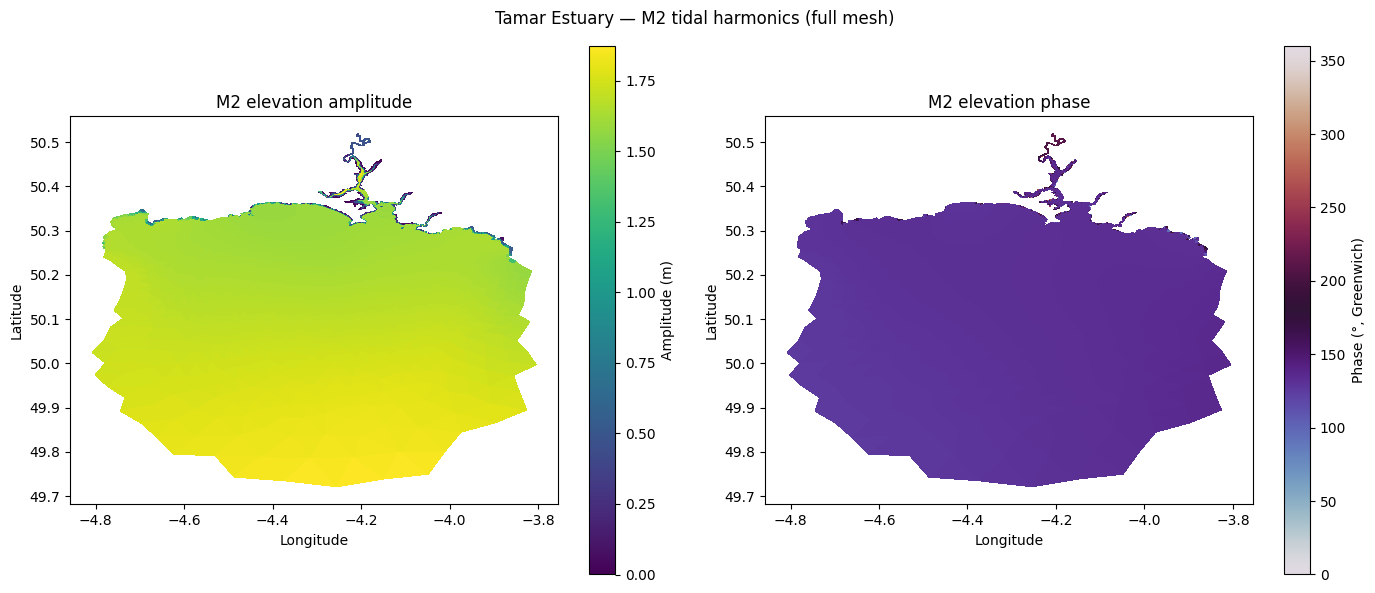

In [6]:
m2_idx = const_names.index('M2')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if SUBSET_BOX is None:
    # ── Full mesh: tripcolor on the triangulation ─────────────────────────
    triang = mtri.Triangulation(lon, lat, nv)
    axes[0].tripcolor(triang, z_amp[m2_idx, :], cmap='viridis', shading='flat')
    im1 = axes[0].tripcolor(triang, z_amp[m2_idx, :], cmap='viridis', shading='flat')
    im2 = axes[1].tripcolor(triang, z_phase[m2_idx, :], cmap='twilight', shading='flat',
                            norm=mcolors.Normalize(vmin=0, vmax=360))
else:
    # ── Subset: scatter (nv connectivity is not valid for a spatial subset) ─
    triang = None
    im1 = axes[0].scatter(lon, lat, c=z_amp[m2_idx, :], cmap='viridis', s=4,
                          vmin=0)
    im2 = axes[1].scatter(lon, lat, c=z_phase[m2_idx, :], cmap='twilight', s=4,
                          norm=mcolors.Normalize(vmin=0, vmax=360))

plt.colorbar(im1, ax=axes[0]).set_label('Amplitude (m)')
plt.colorbar(im2, ax=axes[1]).set_label('Phase (°, Greenwich)')
for ax, title in zip(axes, ['M2 elevation amplitude', 'M2 elevation phase']):
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title)
    ax.set_aspect('equal')

suffix = f'subset {SUBSET_BOX}' if SUBSET_BOX else 'full mesh'
fig.suptitle(f'Tamar Estuary — M2 tidal harmonics ({suffix})', fontsize=12)
plt.tight_layout()
plt.show()


## 5. Plot M2 depth-averaged current ellipses (ua, va)

The depth-averaged M2 current amplitude can be visualised as a vector
magnitude at element centroids.  A full tidal ellipse plot would require
amplitude and phase for both u and v components; here we plot the scalar
magnitude for brevity.

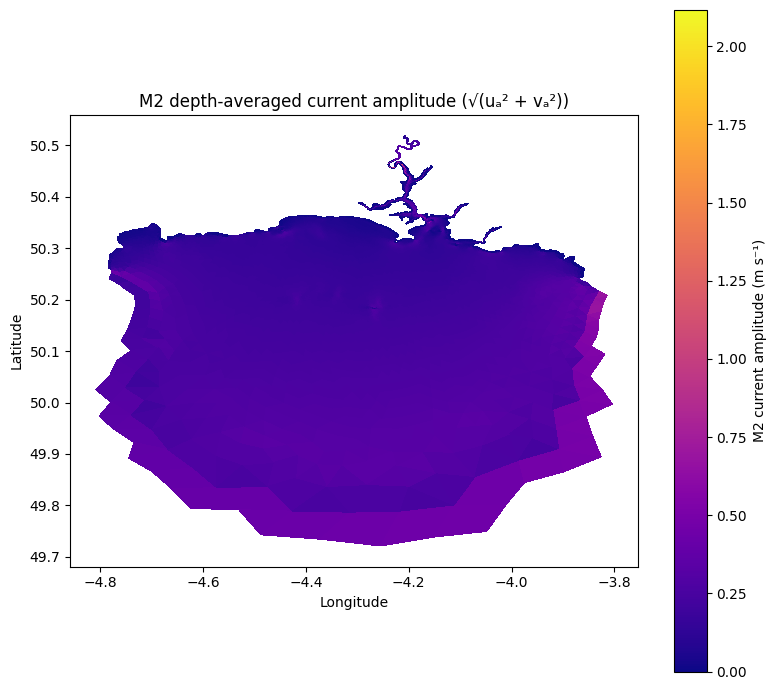

In [7]:
# M2 current speed amplitude at element centres
m2_speed = np.sqrt(ua_amp[m2_idx, :]**2 + va_amp[m2_idx, :]**2)

fig, ax = plt.subplots(figsize=(8, 7))
if SUBSET_BOX is None:
    triang_elem = mtri.Triangulation(lon, lat, nv)
    tc = ax.tripcolor(triang_elem, m2_speed, cmap='plasma', shading='flat')
else:
    tc = ax.scatter(lonc, latc, c=m2_speed, cmap='plasma', s=4)
plt.colorbar(tc, ax=ax).set_label('M2 current amplitude (m s⁻¹)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('M2 depth-averaged current amplitude (√(uₐ² + vₐ²))')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()


## 6. Sanity check: FVCOM M2 vs TPXO10 Atlas

A useful sanity check is to compare the FVCOM M2 harmonic at each node against
the collocated TPXO10 Atlas value. Two physically meaningful diagnostics are:

- **Amplitude ratio** `FVCOM / TPXO` — should be ~1 at the open boundary
  (where FVCOM was almost certainly forced from TPXO or a similar atlas) and
  increase toward the estuary head due to convergence amplification.
- **Phase difference** `FVCOM − TPXO` (normalised to [−180°, 180°]) — should
  be ~0° at the boundary and increase smoothly up-estuary as the tidal wave
  propagates inland. Negative values deep in the estuary would be physically
  implausible. However, the the data being used for the comparison (TPXO) and
  that used to force the FVCOM simulation (CMEMS AMM15 data) are different,
  so some differences may exist.

Nodes where the TPXO amplitude is very small (typically dry land filled with
the nearest wet-cell value) are masked before computing the ratio.

> **Note:** TPXO10 Atlas at 1/30° resolution cannot resolve the Tamar Estuary;
> significant divergence from TPXO inside the estuary is expected and physically
> correct, not indicative of an error in the FVCOM analysis.


Nodes with TPXO amp > 0.05 m : 39,910 / 39,910
Median amplitude ratio : 0.943
Median phase difference: -21.1°


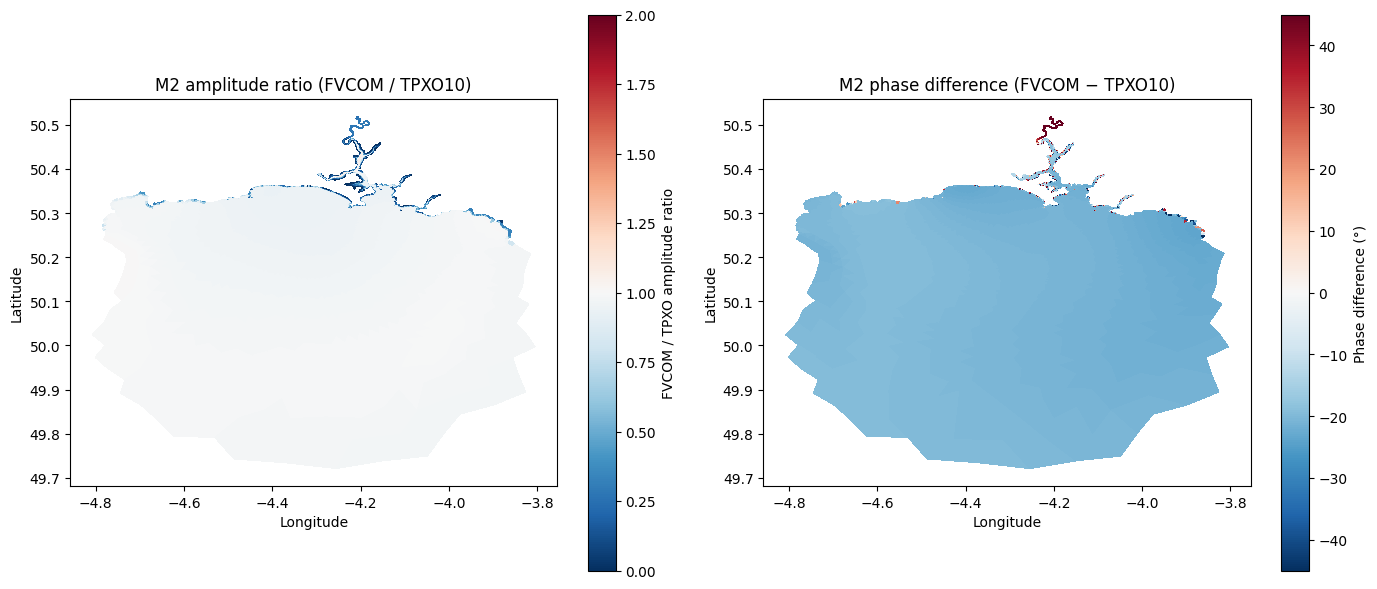

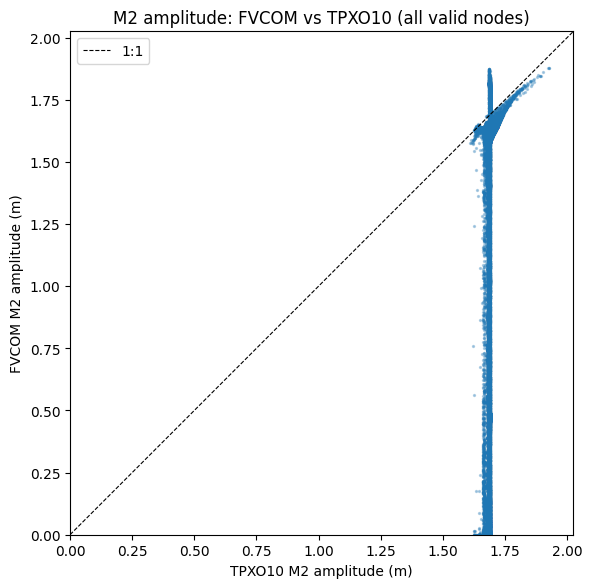

In [8]:
# ── Load TPXO M2 and interpolate to FVCOM node positions ─────────────────────
margin = 1.0
bbox = (lon.min() - margin, lon.max() + margin,
        lat.min() - margin, lat.max() + margin)

tpxo_h_files = {c: f'{TPXO_DIR}/h_{c.lower()}_tpxo10_atlas_30_v2.nc'
                for c in CONSTIT}
h_reader    = TPXOComplexHarmonicsReader(tpxo_h_files)
h_var_names = get_tpxo_complex_harmonics_names('zeta')
h_harmonics = h_reader.read_harmonics(
    list(CONSTIT), h_var_names, fill_land=True, bbox=bbox, bbox_margin=0.1,
)

interp_coords = InterpolationCoordinates(
    dates=None, x3=None,
    x1=lon, x2=lat,
    horizontal_coordinate_system='geographic',
    vertical_coordinate_system='z',
)
h_result = TPXOInterpolator(h_harmonics).interpolate(interp_coords)

tpxo_amp_all   = np.asarray(h_result.amplitudes)   # (n_nodes, n_constit)
tpxo_phase_all = np.asarray(h_result.phases) % 360 # normalise to [0°, 360°)

tpxo_m2_amp   = tpxo_amp_all[:, list(CONSTIT).index('M2')]
tpxo_m2_phase = tpxo_phase_all[:, list(CONSTIT).index('M2')]

# ── Diagnostics ───────────────────────────────────────────────────────────────
AMP_THRESHOLD = 0.05   # mask nodes where TPXO amplitude is negligible (m)
valid = tpxo_m2_amp > AMP_THRESHOLD

fvcom_m2_amp   = z_amp[m2_idx, :]    # already loaded in cell 7
fvcom_m2_phase = z_phase[m2_idx, :]

amp_ratio  = np.where(valid, fvcom_m2_amp / tpxo_m2_amp, np.nan)
phase_diff = np.where(valid,
                      ((fvcom_m2_phase - tpxo_m2_phase) + 180) % 360 - 180,
                      np.nan)

print(f'Nodes with TPXO amp > {AMP_THRESHOLD} m : {valid.sum():,} / {len(valid):,}')
print(f'Median amplitude ratio : {np.nanmedian(amp_ratio):.3f}')
print(f'Median phase difference: {np.nanmedian(phase_diff):.1f}°')

# ── Maps ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if SUBSET_BOX is None:
    im0 = axes[0].tripcolor(triang, amp_ratio, cmap='RdBu_r', shading='flat',
                            norm=mcolors.TwoSlopeNorm(vcenter=1.0, vmin=0.0, vmax=2.0))
    im1 = axes[1].tripcolor(triang, phase_diff, cmap='RdBu_r', shading='flat',
                            norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-45, vmax=45))
else:
    im0 = axes[0].scatter(lon, lat, c=amp_ratio,
                          cmap='RdBu_r', s=4,
                          norm=mcolors.TwoSlopeNorm(vcenter=1.0, vmin=0.0, vmax=2.0))
    im1 = axes[1].scatter(lon, lat, c=phase_diff,
                          cmap='RdBu_r', s=4,
                          norm=mcolors.TwoSlopeNorm(vcenter=0, vmin=-45, vmax=45))

cb0 = plt.colorbar(im0, ax=axes[0])
cb0.set_label('FVCOM / TPXO amplitude ratio')
cb1 = plt.colorbar(im1, ax=axes[1])
cb1.set_label('Phase difference (°)')
for ax, title in zip(axes, ['M2 amplitude ratio (FVCOM / TPXO10)',
                             'M2 phase difference (FVCOM − TPXO10)']):
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(title)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# ── Scatter plot (only meaningful if TPXO has spatial variation) ──────────────
tpxo_range = np.nanmax(tpxo_m2_amp[valid]) - np.nanmin(tpxo_m2_amp[valid])
if tpxo_range < 0.1:
    print(
        f'Scatter plot skipped: TPXO M2 amplitude range is only {tpxo_range*100:.1f} cm '
        f'across the {valid.sum():,} valid nodes — TPXO resolution (~3.7 km) does not '
        f'resolve this spatial subset. Run with SUBSET_BOX = None for a meaningful comparison.'
    )
else:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(tpxo_m2_amp[valid], fvcom_m2_amp[valid],
               s=2, alpha=0.3, color='C0', rasterized=True)
    lim = max(tpxo_m2_amp[valid].max(), fvcom_m2_amp[valid].max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='1:1')
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel('TPXO10 M2 amplitude (m)')
    ax.set_ylabel('FVCOM M2 amplitude (m)')
    ax.set_title('M2 amplitude: FVCOM vs TPXO10 (all valid nodes)')
    ax.legend()
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()


## 7. Notes on extending the workflow

### Longer records
Pass a list of FVCOM output files to `FVCOMReader` to form a continuous
multi-month time series, then use the full `DEFAULT_CONSTIT` constituent set
from `pyfvcom2.tide`.

### Depth-resolved analysis (u, v)
Add `'u'` and `'v'` to the `analyser.run(...)` call.  `HarmonicsAnalyser`
loops over sigma layers internally; output arrays gain a `siglay` dimension:

```python
analyser.run(['zeta', 'ua', 'va', 'u', 'v'])
```

### Reconstructed time series
Set `predict=True` in `HarmonicsAnalyser.__init__` to also write a
UTide-reconstructed tidal signal for each variable and depth level.  A `time`
dimension is added automatically to the output file.

